# Module 10 - Session 2: Practical Exercises

**Total Time Estimate:** 90-120 minutes

**Objective:** To gain hands-on experience identifying bias in a real-world dataset and to think critically about the implications of fairness metrics.


## Setup

Install required libraries:

```bash
pip install pandas matplotlib seaborn scikit-learn
```

Dataset source used in this notebook (UCI Adult Census Income):
- https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data


## Exercise 1: Conceptual Questions (30 minutes)

### 1) Types of Bias
At least two biases are present:

1. **Representation (Sampling) Bias:** The training data is based on popular influencer photos, which likely over-represents light-skinned people and specific beauty standards, so the model does not learn robust behavior for darker skin tones.
2. **Measurement / Labeling Bias:** The optimization target for "good enhancement" is implicitly tied to subjective aesthetics from a narrow group, so the model learns transformations that can make dark skin appear unnatural or washed out.

A related third issue is **historical/social bias** because existing media trends already favor certain appearances, and the model inherits that imbalance.

### 2) Fairness Metrics in Practice
**Equal Opportunity** is more aligned with the stated goal. The city wants neighborhoods with similar true fire risk to receive similar resource outcomes regardless of demographics. That maps to equalizing performance on relevant positive cases (high-risk neighborhoods), rather than forcing equal allocation rates across all neighborhoods as Demographic Parity would.

### 3) The Limits of Mitigation
Even without an explicit `gender` column, resume features can proxy for gender, such as:
- First name and title (`Mr.`, `Ms.`)
- Career gaps (often correlated with caregiving patterns)
- College major and historical occupation patterns
- Membership in gender-coded organizations or clubs
- Word-choice/style patterns in personal summaries
- Past employers or roles with known gender skews

So bias can persist through correlated features unless mitigation addresses proxies, outcomes, and decision policy.


## Exercise 2: Auditing the "Adult" Income Dataset for Bias (60 minutes)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')


In [2]:
# Load the Adult dataset from UCI
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
df = pd.read_csv(url, header=None, names=columns, na_values=' ?', skipinitialspace=True)

print('Shape:', df.shape)
df.head()


Shape: (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
# Overall percentage with income >50K
overall_high_income_pct = (df['income'] == '>50K').mean() * 100
print(f"Overall % with income >50K: {overall_high_income_pct:.2f}%")


Overall % with income >50K: 24.08%


In [4]:
# Analyze by gender (sex)
gender_high_income = (
    df.groupby('sex')['income']
      .apply(lambda s: (s == '>50K').mean() * 100)
      .sort_values(ascending=False)
)

print('Percentage with income >50K by sex:')
print(gender_high_income.round(2))


Percentage with income >50K by sex:
sex
Male      30.57
Female    10.95
Name: income, dtype: float64


In [5]:
# Analyze by race
race_high_income = (
    df.groupby('race')['income']
      .apply(lambda s: (s == '>50K').mean() * 100)
      .sort_values(ascending=False)
)

print('Percentage with income >50K by race:')
print(race_high_income.round(2))


Percentage with income >50K by race:
race
Asian-Pac-Islander    26.56
White                 25.59
Black                 12.39
Amer-Indian-Eskimo    11.58
Other                  9.23
Name: income, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_23952\1576699402.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=gender_high_income.index, y=gender_high_income.values, palette='Blues_d')


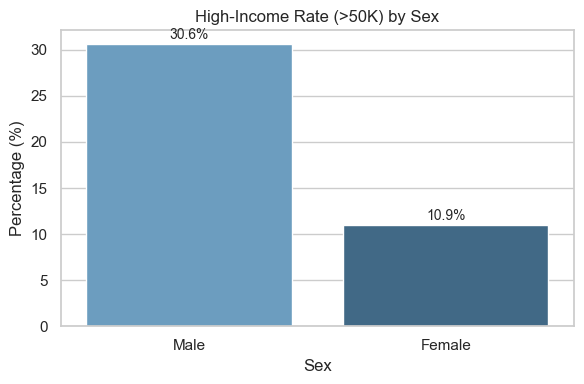

In [6]:
# Visualization 1: High-income percentage by gender
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=gender_high_income.index, y=gender_high_income.values, palette='Blues_d')
ax.set_title('High-Income Rate (>50K) by Sex')
ax.set_xlabel('Sex')
ax.set_ylabel('Percentage (%)')
for i, v in enumerate(gender_high_income.values):
    ax.text(i, v + 0.6, f'{v:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_23952\1711404223.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=race_high_income.index, y=race_high_income.values, palette='Greens_d')


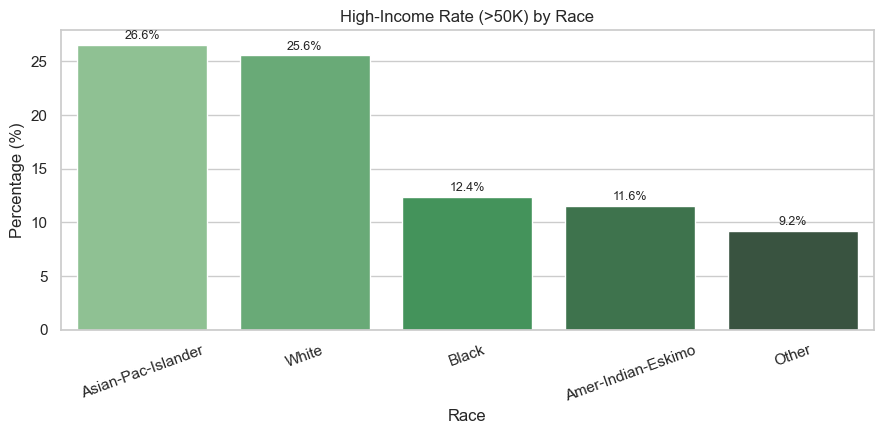

In [7]:
# Visualization 2: High-income percentage by race
plt.figure(figsize=(9, 4.5))
ax = sns.barplot(x=race_high_income.index, y=race_high_income.values, palette='Greens_d')
ax.set_title('High-Income Rate (>50K) by Race')
ax.set_xlabel('Race')
ax.set_ylabel('Percentage (%)')
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(race_high_income.values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


### Conclusion
The dataset shows substantial disparities. Overall, about **24.08%** of individuals have income above $50K. By sex, the high-income rate is about **30.57% for males** versus **10.95% for females**, which is a large demographic-parity gap. By race, rates also differ meaningfully (for example, about **26.56%** for Asian-Pac-Islander and **25.59%** for White, compared to **12.39%** for Black, **11.58%** for Amer-Indian-Eskimo, and **9.23%** for Other). If we train a model on this data without mitigation, it will likely learn and reproduce these historical outcome imbalances, potentially assigning lower predicted income probabilities to groups that are already underrepresented in higher-income labels.


## Exercise 3: Challenge Problem - The Paradox of Fairness

The post-processing fix is effective at one narrow target, but it can produce serious side effects. If Group A historically has lower default risk than Group B, forcing both groups to exactly 50% approval can shift the portfolio toward higher expected default, increasing charge-offs and reducing profitability. Depending on margin structure, the bank might compensate by raising interest rates, tightening credit elsewhere, or cutting approval volume overall, which can indirectly hurt all applicants.

Equalizing approval rates can also conflict with Equal Opportunity. If the groups have different score distributions, a strict parity constraint may reject more qualified applicants in one group and approve less qualified applicants in the other. That means people with similar repayment ability may not be treated similarly, which creates a different kind of unfairness. In practice, fairness definitions can be mutually incompatible, so optimizing one metric can degrade another.

This is why fairness cannot be solved as a purely technical patch. The data scientist's role is to surface tradeoffs with evidence: expected default changes, calibration impacts, false-positive/false-negative differences, and subgroup effects across multiple protected attributes. The data scientist should also propose alternative interventions such as threshold adjustments with constraints, improved feature governance, and human review for borderline cases.

Business and policy leaders, however, must make the normative choice about which fairness objective is appropriate, what risk level is acceptable, and how legal, social, and economic costs should be balanced. Those choices require governance, accountability, and stakeholder input, not just model tuning. The key lesson is that "fairness" is a policy decision implemented through technical methods, not a single metric to maximize.
